## **Highly-Mixed VS Sparse Scenarios**

In [ ]:
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.figure import Figure
from unmixing import classical_distance_to_probability
from unmixing_min_norm_point_PYTHON import generate_half_spaces

seed = 156884

np.random.seed(seed)
sk.random.seed(seed)

In [2]:
n_classes = 3
dimension = 2

mode = 0
if mode == 0: # highly-mixed
    n_samples = 200 #100
    add_dim = False #True
    M_disparity = 0.8 #0.8
    cluster_std = 1.0 #2.0
    A_noise_prop = 0.20 #0.0
    distance_to_M = 10.0 #0.0
    Y_noise_prop = 0.20 #0.0
    E_prop = 0.05 #0.05
else: # sparse
    n_samples = 200 #100
    add_dim = False #True
    M_disparity = 0.8 #0.8
    cluster_std = 2.0 #2.0
    A_noise_prop = 1.00 #0.0
    distance_to_M = 0.4 #0.0
    Y_noise_prop = 0.00 #0.0
    E_prop = 0.05 #0.05

##### Generate random endmembers M

In [3]:
M = generate_half_spaces(n_classes, dimension, radius=1.0, disparity=M_disparity)[:,1].T
if float(add_dim) > 0:
    M = np.concatenate([M, np.full(shape=(1,*M.shape[1:]), fill_value=float(add_dim), dtype=M.dtype)], axis=0)

##### Generate random abundances A

In [ ]:
blob_pts, blob_ids, blob_ctr = sk.datasets.make_blobs(n_samples=n_samples, n_features=n_classes, centers=n_classes, cluster_std=cluster_std, return_centers=True)

A = np.linalg.norm(blob_pts[:,None] - blob_ctr, axis=-1)
A = A * (1 + (np.random.rand(*A.shape)*2-1) * A_noise_prop) + distance_to_M# if A_noise_prop > 0 else A + distance_to_M
A = classical_distance_to_probability(A).T

##### Deduce observations Y + add little noise

In [5]:
Y = M @ A
Y+= (np.random.rand(*Y.shape) * 2 - 1) * Y_noise_prop # noise cloud
A = M.T @ np.linalg.inv(M @ M.T) @ Y # recover abundance matrix A
Y+= (np.random.rand(*Y.shape) * 2 - 1) * E_prop # add little noise E

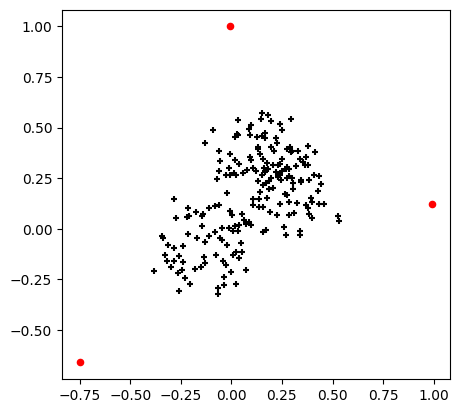

In [6]:
plt.scatter(M[0], -M[1], s=20, c='red')
plt.scatter(Y[0], -Y[1], s=15, c='black', marker='+')
#plt.scatter(0, 0, s=20, c='yellow', marker='*')
plt.gca().set_aspect('equal')
plt.show()

---

In [7]:
extension:str = 'pdf'
folder:str = '/home/abottenmuller/Documents/SIIMS2026/paper/figures/'
text:bool = False # whether to add text to figures

text_size = 14
simplex_color = (0, 0, 0)

In [8]:
# -- Configuration style LaTeX-like --
plt.rcParams.update({
    "text.usetex": True,                   # Utilise LaTeX pour le texte
    "font.family": "serif",                # Famille de base
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,                  # Taille des labels axes
    "font.size": 12,                       # Taille police globale
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "text.latex.preamble": r"\usepackage{amsmath}"  # pour équations si besoin
})

In [9]:
depth = 1.0
M = np.concatenate([M, np.full(shape=(1,*M.shape[1:]), fill_value=depth, dtype=M.dtype)], axis=0)

pad = M[:2].std() * 0.3
pad_x = (M[1].max() - M[1].min() - min(M[0].max() - M[0].min(), M[1].max() - M[1].min())) / 2 + pad
pad_y = (M[0].max() - M[0].min() - min(M[0].max() - M[0].min(), M[1].max() - M[1].min())) / 2 + pad
min_x, max_x = M[0].min() - pad_x, M[0].max() + pad_x
min_y, max_y = M[1].min() - pad_y, M[1].max() + pad_y

length = 200

lx = np.linspace(min_x, max_x, length)
ly = np.linspace(min_y, max_y, length)
grid = np.meshgrid(lx, ly)
grid = np.asarray(grid).reshape(len(grid), np.prod(grid[0].shape))
grid = np.concatenate([grid, np.full(shape=(1,*grid.shape[1:]), fill_value=depth, dtype=grid.dtype)], axis=0)

M_inv = np.linalg.inv(M) # inverse matrix of M (or pseudo-inverse, if M is not invertible)
grid_A = M_inv @ grid

grid_A_img = grid_A.T.reshape(*(int(np.sqrt(grid_A[0].shape[0])),)*2, len(grid_A))
mul = length / (max_x - min_x)

area_under_0 = grid_A_img < 0 #- 1e-2
area_above_1 = grid_A_img > 1 #+ 1e-2
area_is1_sum = np.isclose(grid_A_img.sum(-1), 1.0)

mask = np.prod(~area_under_0, axis=-1, dtype=bool) # comme la somme fait 1, si tous les éléments sont > 0, alors aucun n'est > 1 (donc 'area_above_1' n'est pas nécessaire!)
grid_A_img_masked = grid_A_img.copy()
grid_A_img_masked[~mask] = 1.0

dirs = M - M.mean(axis=1, keepdims=True)
dirs_norm = np.linalg.norm(dirs, axis=1, keepdims=True)
dirs = dirs * ~np.isclose(dirs_norm,0) / (dirs_norm + np.isclose(dirs_norm,0))
dirs = dirs * (0.9 + 0.1 * np.abs(dirs[1]) + 0.8 * dirs[1] * (dirs[1] > 0))
dirs = dirs * length * 0.05

grid_A_img_masked_RGBA = np.concatenate([grid_A_img_masked, mask[...,None].astype(grid.dtype)], axis=-1)

In [10]:
if mode == 0:
    name = 'example_high'
else:
    name = 'example_low'

fg = Figure()
ax = fg.add_subplot(1,1,1)

ax.imshow((grid_A_img_masked_RGBA>0).astype(np.uint8), extent=(0, grid_A_img_masked_RGBA.shape[0], grid_A_img_masked_RGBA.shape[1], 0), zorder=1)

for i in range(M.shape[1]):
    ax.plot([(M[0,i-1]-min_x)*mul, (M[0,i]-min_x)*mul], [(M[1,i-1]-min_y)*mul, (M[1,i]-min_y)*mul], color=simplex_color, linewidth=2.5, zorder=i+2)

for i in range(M.shape[1]):
    color = (0.5*(i==0)+0.1*(i==2), 0.5*(i==1)+0.1*(i==2), 0.6*(i==2))
    ax.scatter((M[0,i]-min_x)*mul, (M[1,i]-min_y)*mul, s=40, color='black', facecolor=color, zorder=M.shape[1]+3+2*i)
    if text:
        ax.text((M[0,i]-min_x)*mul + dirs[0,i], (M[1,i]-min_y)*mul + dirs[1,i], s=rf"$M_{i+1}$", size=text_size, color=color, zorder=M.shape[1]+3+2*i+1)

ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=8, color='black', marker='o', facecolors='none', linewidths=0.6, zorder=3*M.shape[1]+3)
#ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=15, c='black', marker='+', linewidths=0.5, zorder=3*M.shape[1]+3)
#ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=10, c='black', marker='x', linewidths=0.5, zorder=3*M.shape[1]+4)

ax.scatter(length * 0.602, length * 0.875, s=16, color='black', facecolor=(0.5,0.0,0.0), marker='o', linewidths=0.7, zorder=3*M.shape[1]+10)
ax.scatter(length * 0.579, length * 0.875, s=16, color='black', facecolor=(0.0,0.5,0.0), marker='o', linewidths=0.7, zorder=3*M.shape[1]+11)
ax.scatter(length * 0.590, length * 0.855, s=16, color='black', facecolor=(0.1,0.1,0.6), marker='o', linewidths=0.7, zorder=3*M.shape[1]+12)

if text:
    ax.text(length * 0.09, length * 0.37, s="simplex", size=text_size, color=simplex_color, weight='bold', zorder=3*M.shape[1]+5)
    ax.text(length * 0.41, length * 0.49, s=r"$Y$", size=text_size*1.5, color='black', weight='bold', zorder=3*M.shape[1]+6)
    ax.text(length * 0.622, length * 0.878, s=r": endmembers", size=text_size, color='black', weight='bold', zorder=3*M.shape[1]+10)

ax.set_aspect('equal')
ax.set_axis_off()

fn = Path(folder + name + '.' + extension).expanduser()
fg.savefig(fn, bbox_inches='tight', pad_inches=0, transparent=True)

---

## **Linear Independence Case**

In [ ]:
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.figure import Figure
from matplotlib.patches import Polygon
from unmixing import classical_distance_to_probability
from unmixing_min_norm_point_PYTHON import generate_half_spaces

seed = 156884

np.random.seed(seed)
sk.random.seed(seed)

In [4]:
n_classes = 3

##### Generate random endmembers M

In [5]:
depth = 1.0 # vector values on z axis (depth)
M = generate_half_spaces(n_classes, n_classes-1, radius=1.0, disparity=0.8)[:,1].T
M = np.concatenate([M, np.full(shape=(1,*M.shape[1:]), fill_value=depth, dtype=M.dtype)], axis=0)

##### Generate random abundances A

In [ ]:
blob_pts, blob_ids, blob_ctr = sk.datasets.make_blobs(n_samples=100, n_features=n_classes, cluster_std=2.0, return_centers=True) # they are distributed into clusters

A = np.linalg.norm(blob_pts[:,None] - blob_ctr, axis=-1)
A = classical_distance_to_probability(A).T

##### Deduce observations Y + add little noise

In [7]:
Y = M @ A
Y+= (np.random.rand(*Y.shape) * 2 - 1) * 0.05 # add little noise

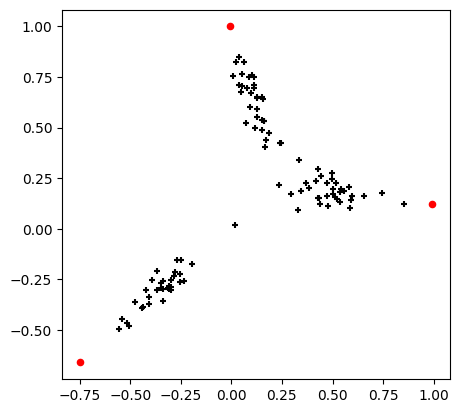

In [8]:
plt.scatter(M[0], -M[1], s=20, c='red')
plt.scatter(Y[0], -Y[1], s=15, c='black', marker='+')
plt.gca().set_aspect('equal')
plt.show()

In [9]:
pad = M[:2].std() * 0.3
pad_x = (M[1].max() - M[1].min() - min(M[0].max() - M[0].min(), M[1].max() - M[1].min())) / 2 + pad
pad_y = (M[0].max() - M[0].min() - min(M[0].max() - M[0].min(), M[1].max() - M[1].min())) / 2 + pad
min_x, max_x = M[0].min() - pad_x, M[0].max() + pad_x
min_y, max_y = M[1].min() - pad_y, M[1].max() + pad_y

In [10]:
length = 200

lx = np.linspace(min_x, max_x, length)
ly = np.linspace(min_y, max_y, length)
grid = np.meshgrid(lx, ly)
grid = np.asarray(grid).reshape(len(grid), np.prod(grid[0].shape))
grid = np.concatenate([grid, np.full(shape=(1,*grid.shape[1:]), fill_value=depth, dtype=grid.dtype)], axis=0)

In [11]:
M_inv = np.linalg.inv(M) # inverse matrix of M (or pseudo-inverse, if M is not invertible)
grid_A = M_inv @ grid

In [12]:
grid_A_img = grid_A.T.reshape(*(int(np.sqrt(grid_A[0].shape[0])),)*2, len(grid_A))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8506319382231282..1.5125755571388135].


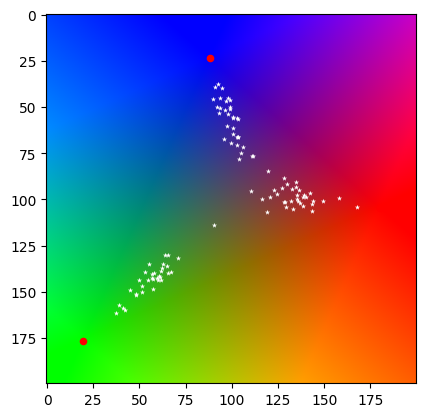

In [13]:
mul = length / (max_x - min_x)
plt.imshow(grid_A_img)
plt.scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=20, c='red')
plt.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=15, c='white', marker='*', linewidths=0.0001)
plt.gca().set_aspect('equal')
plt.show()

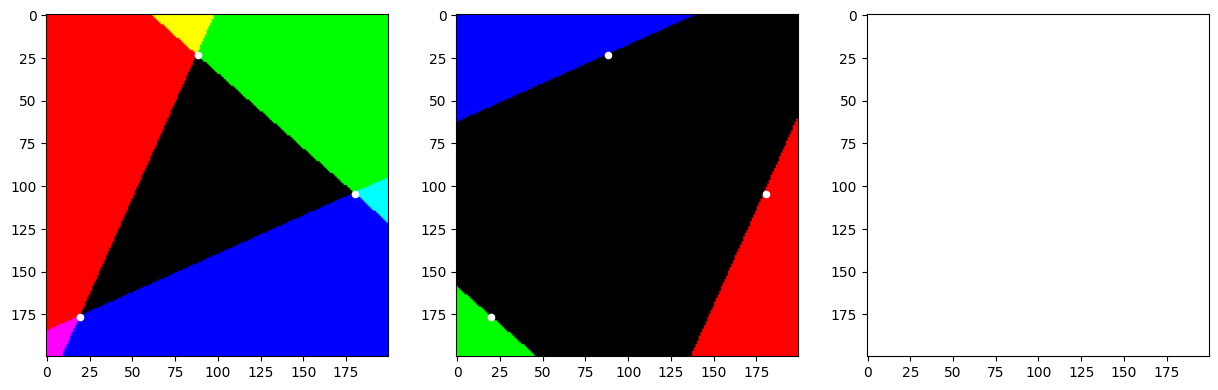

In [14]:
area_under_0 = grid_A_img < 0 #- 1e-2
area_above_1 = grid_A_img > 1 #+ 1e-2
area_is1_sum = np.isclose(grid_A_img.sum(-1), 1.0)

fig, ax = plt.subplots(1,3,figsize=(15,6))
ax[0].imshow((area_under_0*255).astype(np.uint8))
ax[0].scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=20, c='white')
ax[1].imshow((area_above_1*255).astype(np.uint8))
ax[1].scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=20, c='white')
ax[2].imshow(area_is1_sum, cmap='gray', vmin=0, vmax=1)
plt.gca().set_aspect('equal')
plt.show()

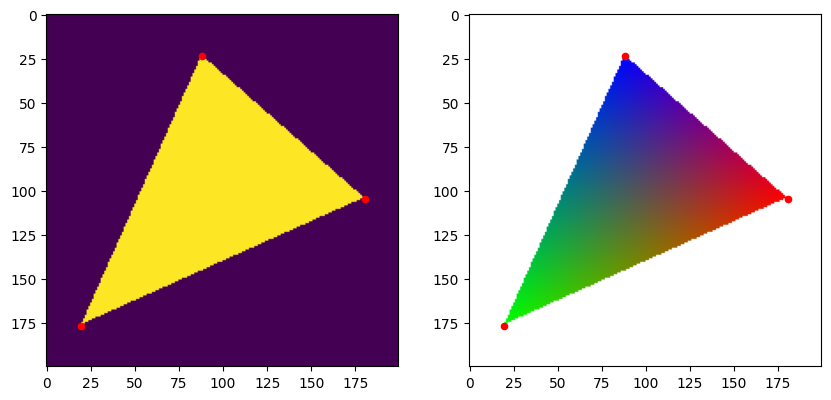

In [15]:
mask = np.prod(~area_under_0, axis=-1, dtype=bool) # comme la somme fait 1, si tous les éléments sont > 0, alors aucun n'est > 1 (donc 'area_above_1' n'est pas nécessaire!)
grid_A_img_masked = grid_A_img.copy()
grid_A_img_masked[~mask] = 1.0

fig, ax = plt.subplots(1,2,figsize=(10,6))
ax[0].imshow((mask*255).astype(np.uint8))
ax[0].scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=20, c='red')
ax[1].imshow(grid_A_img_masked)
ax[1].scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=20, c='red')
plt.gca().set_aspect('equal')
plt.show()

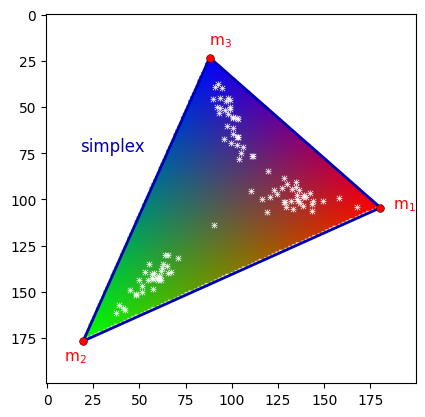

In [16]:
dirs = M - M.mean(axis=1, keepdims=True)
dirs_norm = np.linalg.norm(dirs, axis=1, keepdims=True)
dirs = dirs * ~np.isclose(dirs_norm,0) / (dirs_norm + np.isclose(dirs_norm,0))
dirs = dirs * (0.9 + 0.1 * np.abs(dirs[1]) + 0.8 * dirs[1] * (dirs[1] > 0))
dirs = dirs * length * 0.05

plt.imshow(grid_A_img_masked, zorder=1)
for i in range(M.shape[1]):
    plt.plot([(M[0,i-1]-min_x)*mul, (M[0,i]-min_x)*mul], [(M[1,i-1]-min_y)*mul, (M[1,i]-min_y)*mul], color=(0.0, 0.0, 0.7), linewidth=2, zorder=i+2)
plt.scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=25, c='black', zorder=M.shape[1]+2)
plt.scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=20, c='red', zorder=M.shape[1]+3)
for i in range(M.shape[1]):
    plt.text((M[0,i]-min_x)*mul + dirs[0,i], (M[1,i]-min_y)*mul + dirs[1,i], s=rf"m$_{i+1}$", size=11, c='red', zorder=M.shape[1]+3+i)
plt.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=15, c='white', marker='+', linewidths=0.5, zorder=2*M.shape[1]+3)
plt.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=15, c='white', marker='x', linewidths=0.5, zorder=2*M.shape[1]+4)
plt.text(length * 0.09, length * 0.37, s="simplex", size=12, color=(0.0, 0.0, 0.7), zorder=2*M.shape[1]+5)
plt.gca().set_aspect('equal')
plt.show()

In [17]:
# * [OK] LaTeX font for text!
# * [OK] remove grid (axes) and padding!
# * [OK] increase space resolution of colors
# * [OK] add labels (colors, i.e., =abundances)
# * [OK] replace white with transparency

In [18]:
# -- Configuration style LaTeX-like --
plt.rcParams.update({
    "text.usetex": True,                   # Utilise LaTeX pour le texte
    "font.family": "serif",                # Famille de base
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,                  # Taille des labels axes
    "font.size": 12,                       # Taille police globale
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "text.latex.preamble": r"\usepackage{amsmath}"  # pour équations si besoin
})

In [19]:
grid_A_img_masked_RGBA = np.concatenate([grid_A_img_masked, mask[...,None].astype(grid.dtype)], axis=-1)

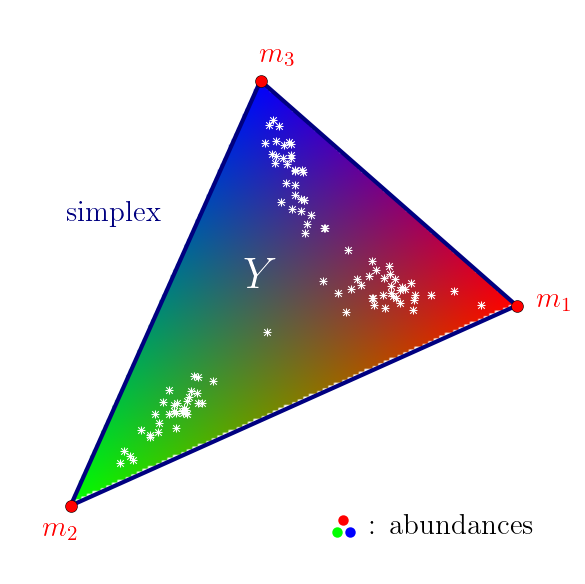

In [20]:
text_size = 14
simplex_color = (0.0, 0.0, 0.5)
plt.imshow(grid_A_img_masked_RGBA, zorder=1)
for i in range(M.shape[1]):
    plt.plot([(M[0,i-1]-min_x)*mul, (M[0,i]-min_x)*mul], [(M[1,i-1]-min_y)*mul, (M[1,i]-min_y)*mul], color=simplex_color, linewidth=2, zorder=i+2)
plt.scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=25, c='black', zorder=M.shape[1]+2)
plt.scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=20, c='red', zorder=M.shape[1]+3)
for i in range(M.shape[1]):
    plt.text((M[0,i]-min_x)*mul + dirs[0,i], (M[1,i]-min_y)*mul + dirs[1,i], s=rf"$m_{i+1}$", size=text_size, c='red', zorder=M.shape[1]+4+i)
plt.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=15, c='white', marker='+', linewidths=0.5, zorder=2*M.shape[1]+4)
plt.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=10, c='white', marker='x', linewidths=0.5, zorder=2*M.shape[1]+5)
plt.text(length * 0.09, length * 0.37, s="simplex", size=text_size, color=simplex_color, weight='bold', zorder=2*M.shape[1]+6)
plt.text(length * 0.41, length * 0.49, s=r"$Y$", size=text_size*1.5, color='white', weight='bold', zorder=2*M.shape[1]+7)
plt.scatter(length * 0.590, length * 0.91, s=16, color=(1,0,0), zorder=2*M.shape[1]+8)
plt.scatter(length * 0.579, length * 0.93, s=16, color=(0,1,0), zorder=2*M.shape[1]+9)
plt.scatter(length * 0.602, length * 0.93, s=16, color=(0,0,1), zorder=2*M.shape[1]+10)
plt.text(length * 0.637, length * 0.933, s=r": abundances", size=text_size, color='black', weight='bold', zorder=2*M.shape[1]+11)
plt.gca().set_aspect('equal')
plt.gca().set_axis_off()
plt.show()

In [21]:
grid_C_img_masked = np.isclose(grid_A_img_masked, np.max(grid_A_img_masked, axis=-1, keepdims=True)).astype(grid_A_img_masked.dtype)
grid_C_img_masked_RGBA = np.concatenate([grid_C_img_masked, mask[...,None].astype(grid_A_img_masked.dtype)], axis=-1)

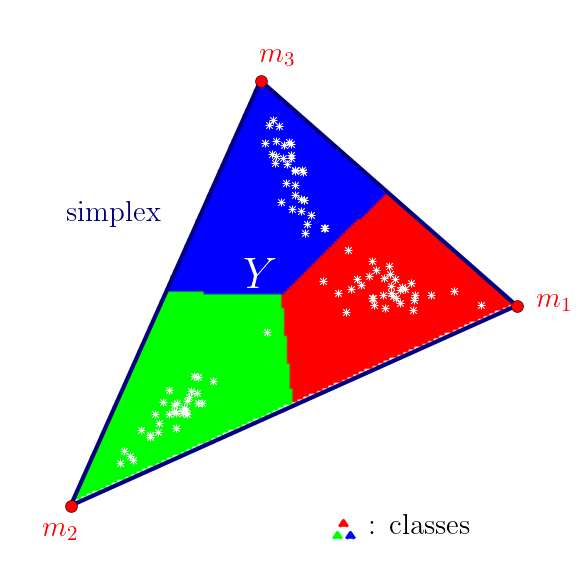

In [22]:
text_size = 14
simplex_color = (0.0, 0.0, 0.5)
plt.imshow(grid_C_img_masked_RGBA, zorder=1)
for i in range(M.shape[1]):
    plt.plot([(M[0,i-1]-min_x)*mul, (M[0,i]-min_x)*mul], [(M[1,i-1]-min_y)*mul, (M[1,i]-min_y)*mul], color=simplex_color, linewidth=2, zorder=i+2)
plt.scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=25, c='black', zorder=M.shape[1]+2)
plt.scatter((M[0]-min_x)*mul, (M[1]-min_y)*mul, s=20, c='red', zorder=M.shape[1]+3)
for i in range(M.shape[1]):
    plt.text((M[0,i]-min_x)*mul + dirs[0,i], (M[1,i]-min_y)*mul + dirs[1,i], s=rf"$m_{i+1}$", size=text_size, c='red', zorder=M.shape[1]+4+i)
plt.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=15, c='white', marker='+', linewidths=0.5, zorder=2*M.shape[1]+4)
plt.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=10, c='white', marker='x', linewidths=0.5, zorder=2*M.shape[1]+5)
plt.text(length * 0.09, length * 0.37, s="simplex", size=text_size, color=simplex_color, weight='bold', zorder=2*M.shape[1]+6)
plt.text(length * 0.41, length * 0.49, s=r"$Y$", size=text_size*1.5, color='white', weight='bold', zorder=2*M.shape[1]+7)
plt.scatter(length * 0.590, length * 0.91, s=16, color=(1,0,0), marker=6, zorder=2*M.shape[1]+8)
plt.scatter(length * 0.579, length * 0.93, s=16, color=(0,1,0), marker=6, zorder=2*M.shape[1]+9)
plt.scatter(length * 0.602, length * 0.93, s=16, color=(0,0,1), marker=6, zorder=2*M.shape[1]+10)
plt.text(length * 0.637, length * 0.933, s=r": classes", size=text_size, color='black', weight='bold', zorder=2*M.shape[1]+11)
plt.gca().set_aspect('equal')
plt.gca().set_axis_off()
plt.show()

##### Compute polyhedral sets!

In [21]:
# Center of the endmembers!
def get_center(M:np.ndarray, warning:bool=False) -> np.ndarray:
    """M is of shape (n_endm=3, ndim=2)"""
    frac_up = (M[0,1] - M[1,1]) * (M[0,0] + M[2,0] - 2 * M[1,0]) - (M[0,0] - M[1,0]) * (M[0,1] + M[2,1] - 2 * M[1,1])
    frac_dw = (M[0,1] + M[2,1] - 2 * M[1,1]) * (M[1,0] + M[2,0] - 2 * M[0,0]) - (M[0,0] + M[2,0] - 2 * M[1,0]) * (M[1,1] + M[2,1] - 2 * M[0,1])
    if np.abs(frac_dw) < 1e-12:
        if warning:
            print("Warning: devide by 0 in get_center function")
        return np.asarray([0]*M.shape[1])
    little_x = M[0,0] + frac_up / frac_dw * (M[1,0] + M[2,0] - 2 * M[0,0])
    little_y = M[0,1] + frac_up / frac_dw * (M[1,1] + M[2,1] - 2 * M[0,1])
    return np.asarray([little_x, little_y] + [0] * (M.shape[1]-2))

# Jonctions!
def inter_point(pa1:np.ndarray, pa2:np.ndarray, pb1:np.ndarray, pb2:np.ndarray, warning:bool=False) -> np.ndarray:
    """p__ are points of shape (2,)"""
    diffa, diffb = pa2 - pa1, pb2 - pb1
    frac_up = diffa[0] * diffb[0] * (pb1[1] - pa1[1]) + diffa[1] * diffb[0] * pa1[0] - diffb[1] * diffa[0] * pb1[0]
    frac_dw = diffa[1] * diffb[0] - diffb[1] * diffa[0]
    if np.abs(frac_dw) < 1e-12 or np.abs(diffa[0]) < 1e-12:
        if warning:
            print("Warning: devide by 0 in get_center function")
        return np.asarray([0]*M.shape[1])
    little_x = frac_up / frac_dw
    little_y = diffa[1] / diffa[0] * (little_x - pa1[0]) + pa1[1]
    return np.asarray([little_x, little_y])

ENDM = (M[:2].T - np.asarray([min_x, min_y])) * mul

center_p = get_center(ENDM)
yellow_p = inter_point(center_p, (ENDM[0] + ENDM[1])/2, ENDM[0], ENDM[1])
cyan_p = inter_point(center_p, (ENDM[1] + ENDM[2])/2, ENDM[1], ENDM[2])
magenta_p = inter_point(center_p, (ENDM[2] + ENDM[0])/2, ENDM[2], ENDM[0])

red_poly = [ENDM[0], yellow_p, center_p, magenta_p]
green_poly = [ENDM[1], cyan_p, center_p, yellow_p]
blue_poly = [ENDM[2], magenta_p, center_p, cyan_p]

poly_regions = np.asarray([red_poly, green_poly, blue_poly])

---

In [23]:
extension:str = 'pdf'
folder:str = '/home/abottenmuller/Documents/SIIMS2026/paper/figures/'
text:bool = False # whether to add text to figures

text_size = 14
simplex_color = (0, 0, 0)

In [23]:
name = 'example_observations_Y'

fg = Figure()
ax = fg.add_subplot(1,1,1)

ax.imshow((grid_A_img_masked_RGBA>0).astype(np.uint8), extent=(0, grid_A_img_masked_RGBA.shape[0], grid_A_img_masked_RGBA.shape[1], 0), zorder=1)

ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=8, color='black', marker='o', facecolors='none', linewidths=0.6, zorder=3*M.shape[1]+3)
#ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=15, c='black', marker='+', linewidths=0.5, zorder=3*M.shape[1]+3)
#ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=10, c='black', marker='x', linewidths=0.5, zorder=3*M.shape[1]+4)

if text:
    ax.text(length * 0.41, length * 0.49, s=r"$Y$", size=text_size*1.5, color='black', weight='bold', zorder=3*M.shape[1]+6)

ax.set_aspect('equal')
ax.set_axis_off()

fn = Path(folder + name + '.pdf').expanduser()
fg.savefig(fn, bbox_inches='tight', pad_inches=0, transparent=True)

In [24]:
name = 'example_endmembers_M'

fg = Figure()
ax = fg.add_subplot(1,1,1)

ax.imshow((grid_A_img_masked_RGBA>0).astype(np.uint8), extent=(0, grid_A_img_masked_RGBA.shape[0], grid_A_img_masked_RGBA.shape[1], 0), zorder=1)

for i in range(M.shape[1]):
    ax.plot([(M[0,i-1]-min_x)*mul, (M[0,i]-min_x)*mul], [(M[1,i-1]-min_y)*mul, (M[1,i]-min_y)*mul], color=simplex_color, linewidth=2.5, zorder=i+2)

for i in range(M.shape[1]):
    color = (0.5*(i==0)+0.1*(i==2), 0.5*(i==1)+0.1*(i==2), 0.6*(i==2))
    ax.scatter((M[0,i]-min_x)*mul, (M[1,i]-min_y)*mul, s=40, color='black', facecolor=color, zorder=M.shape[1]+3+2*i)
    if text:
        ax.text((M[0,i]-min_x)*mul + dirs[0,i], (M[1,i]-min_y)*mul + dirs[1,i], s=rf"$M_{i+1}$", size=text_size, color=color, zorder=M.shape[1]+3+2*i+1)

ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=8, color='black', marker='o', facecolors='none', linewidths=0.6, zorder=3*M.shape[1]+3)
#ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=15, c='black', marker='+', linewidths=0.5, zorder=3*M.shape[1]+3)
#ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=10, c='black', marker='x', linewidths=0.5, zorder=3*M.shape[1]+4)

ax.scatter(length * 0.602, length * 0.875, s=16, color='black', facecolor=(0.5,0.0,0.0), marker='o', linewidths=0.7, zorder=3*M.shape[1]+10)
ax.scatter(length * 0.579, length * 0.875, s=16, color='black', facecolor=(0.0,0.5,0.0), marker='o', linewidths=0.7, zorder=3*M.shape[1]+11)
ax.scatter(length * 0.590, length * 0.855, s=16, color='black', facecolor=(0.1,0.1,0.6), marker='o', linewidths=0.7, zorder=3*M.shape[1]+12)

if text:
    ax.text(length * 0.09, length * 0.37, s="simplex", size=text_size, color=simplex_color, weight='bold', zorder=3*M.shape[1]+5)
    ax.text(length * 0.41, length * 0.49, s=r"$Y$", size=text_size*1.5, color='black', weight='bold', zorder=3*M.shape[1]+6)
    ax.text(length * 0.622, length * 0.878, s=r": endmembers", size=text_size, color='black', weight='bold', zorder=3*M.shape[1]+10)

ax.set_aspect('equal')
ax.set_axis_off()

fn = Path(folder + name + '.' + extension).expanduser()
fg.savefig(fn, bbox_inches='tight', pad_inches=0, transparent=True)

In [25]:
name = 'example_abundances_A'

fg = Figure()
ax = fg.add_subplot(1,1,1)

ax.imshow(grid_A_img_masked_RGBA, extent=(0, grid_A_img_masked_RGBA.shape[0], grid_A_img_masked_RGBA.shape[1], 0), zorder=1)

for i in range(M.shape[1]):
    ax.plot([(M[0,i-1]-min_x)*mul, (M[0,i]-min_x)*mul], [(M[1,i-1]-min_y)*mul, (M[1,i]-min_y)*mul], color=simplex_color, linewidth=2.5, zorder=i+2)

for i in range(M.shape[1]):
    color = (0.5*(i==0)+0.1*(i==2), 0.5*(i==1)+0.1*(i==2), 0.6*(i==2))
    ax.scatter((M[0,i]-min_x)*mul, (M[1,i]-min_y)*mul, s=40, color='black', facecolor=color, zorder=M.shape[1]+3+2*i)
    if text:
        ax.text((M[0,i]-min_x)*mul + dirs[0,i], (M[1,i]-min_y)*mul + dirs[1,i], s=rf"$M_{i+1}$", size=text_size, color=color, zorder=M.shape[1]+3+2*i+1)

ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=8, color='white', marker='o', facecolors='none', linewidths=0.6, zorder=3*M.shape[1]+3)
#ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=15, c='white', marker='+', linewidths=0.5, zorder=3*M.shape[1]+3)
#ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=10, c='white', marker='x', linewidths=0.5, zorder=3*M.shape[1]+4)

ax.scatter(length * 0.602, length * 0.875, s=16, color='black', facecolor=(0.5,0.0,0.0), marker='o', linewidths=0.7, zorder=3*M.shape[1]+10)
ax.scatter(length * 0.579, length * 0.875, s=16, color='black', facecolor=(0.0,0.5,0.0), marker='o', linewidths=0.7, zorder=3*M.shape[1]+11)
ax.scatter(length * 0.590, length * 0.855, s=16, color='black', facecolor=(0.1,0.1,0.6), marker='o', linewidths=0.7, zorder=3*M.shape[1]+12)

ax.scatter(length * 0.602, length * 0.940, s=16, color=(1,0,0), marker='d', zorder=3*M.shape[1]+11)
ax.scatter(length * 0.579, length * 0.940, s=16, color=(0,1,0), marker='d', zorder=3*M.shape[1]+12)
ax.scatter(length * 0.590, length * 0.920, s=16, color=(0,0,1), marker='d', zorder=3*M.shape[1]+13)

if text:
    ax.text(length * 0.09, length * 0.37, s="simplex", size=text_size, color=simplex_color, weight='bold', zorder=3*M.shape[1]+5)
    ax.text(length * 0.41, length * 0.49, s=r"$Y$", size=text_size*1.5, color='white', weight='bold', zorder=3*M.shape[1]+6)
    ax.text(length * 0.622, length * 0.878, s=r": endmembers", size=text_size, color='black', weight='bold', zorder=3*M.shape[1]+10)
    ax.text(length * 0.622, length * 0.943, s=r": abundances", size=text_size, color='black', weight='bold', zorder=3*M.shape[1]+14)

ax.set_aspect('equal')
ax.set_axis_off()

fn = Path(folder + name + '.' + extension).expanduser()
fg.savefig(fn, bbox_inches='tight', pad_inches=0, transparent=True)

In [ ]:
name = 'example_classes_C'

fg = Figure()
ax = fg.add_subplot(1,1,1)

ax.imshow((grid_A_img_masked_RGBA>0).astype(np.uint8), extent=(0, grid_A_img_masked_RGBA.shape[0], grid_A_img_masked_RGBA.shape[1], 0), zorder=1)

for i in range(len(poly_regions)):
    color2D = (1.0, 0.0, 0.0) * (i==0) + (0.0, 1.0, 0.0) * (i==1) + (0.0, 0.0, 1.0) * (i==2)
    color2D = np.asarray(color2D); color2D[color2D>1] = 1; color2D = tuple(color2D)
    pii = poly_regions[i]
    polygon = Polygon(pii, closed=False, facecolor=color2D, alpha=1.0, linewidth=1.0, antialiased=False, zorder=1.1)
    ax.add_patch(polygon)

for i in range(M.shape[1]):
    ax.plot([(M[0,i-1]-min_x)*mul, (M[0,i]-min_x)*mul], [(M[1,i-1]-min_y)*mul, (M[1,i]-min_y)*mul], color=simplex_color, linewidth=2.5, zorder=i+2)

for i in range(M.shape[1]):
    color = (0.5*(i==0)+0.1*(i==2), 0.5*(i==1)+0.1*(i==2), 0.6*(i==2))
    ax.scatter((M[0,i]-min_x)*mul, (M[1,i]-min_y)*mul, s=40, color='black', facecolor=color, zorder=M.shape[1]+3+2*i)
    if text:
        ax.text((M[0,i]-min_x)*mul + dirs[0,i], (M[1,i]-min_y)*mul + dirs[1,i], s=rf"$M_{i+1}$", size=text_size, color=color, zorder=M.shape[1]+3+2*i+1)

ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=8, color='white', marker='o', facecolors='none', linewidths=0.6, zorder=3*M.shape[1]+3)
#ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=15, c='white', marker='+', linewidths=0.5, zorder=3*M.shape[1]+3)
#ax.scatter((Y[0]-min_x)*mul, (Y[1]-min_y)*mul, s=10, c='white', marker='x', linewidths=0.5, zorder=3*M.shape[1]+4)

ax.scatter(length * 0.602, length * 0.875, s=16, color='black', facecolor=(0.5,0.0,0.0), marker='o', linewidths=0.7, zorder=3*M.shape[1]+10)
ax.scatter(length * 0.579, length * 0.875, s=16, color='black', facecolor=(0.0,0.5,0.0), marker='o', linewidths=0.7, zorder=3*M.shape[1]+11)
ax.scatter(length * 0.590, length * 0.855, s=16, color='black', facecolor=(0.1,0.1,0.6), marker='o', linewidths=0.7, zorder=3*M.shape[1]+12)

ax.scatter(length * 0.602, length * 0.940, s=16, color=(1,0,0), marker='d', zorder=3*M.shape[1]+11)
ax.scatter(length * 0.579, length * 0.940, s=16, color=(0,1,0), marker='d', zorder=3*M.shape[1]+12)
ax.scatter(length * 0.590, length * 0.920, s=16, color=(0,0,1), marker='d', zorder=3*M.shape[1]+13)

if text:
    ax.text(length * 0.09, length * 0.37, s="simplex", size=text_size, color=simplex_color, weight='bold', zorder=3*M.shape[1]+5)
    ax.text(length * 0.41, length * 0.49, s=r"$Y$", size=text_size*1.5, color='white', weight='bold', zorder=3*M.shape[1]+6)
    ax.text(length * 0.622, length * 0.878, s=r": endmembers", size=text_size, color='black', weight='bold', zorder=3*M.shape[1]+10)
    ax.text(length * 0.622, length * 0.943, s=r": abundances", size=text_size, color='black', weight='bold', zorder=3*M.shape[1]+14)

ax.set_aspect('equal')
ax.set_axis_off()

fn = Path(folder + name + '.' + extension).expanduser()
fg.savefig(fn, bbox_inches='tight', pad_inches=0, transparent=True)

---

## **Linear Dependence Case**

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import path
from matplotlib.patches import Polygon
from sklearn.decomposition import PCA
from unmixing_min_norm_point_PYTHON import generate_half_spaces, normed, norm, scalar

seed = 156884
np.random.seed(seed)

In [346]:
# -- Configuration style LaTeX-like --
plt.rcParams.update({
    "text.usetex": True,                   # Utilise LaTeX pour le texte
    "font.family": "serif",                # Famille de base
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 10,                  # Taille des labels axes
    "font.size": 10,                       # Taille police globale
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 120,                     # DPI de la figure showed
    "savefig.dpi": 200,                    # DPI du PDF saved
    "text.latex.preamble": r"\usepackage{amsmath}"  # pour equations si besoin
})

In [ ]:
extension:str = 'pdf'
folder:str = '/home/abottenmuller/Documents/SIIMS2026/paper/figures/raw/'
text:bool = False # whether to add text to figures

W_rotation  = 0.2 # from -1.0 to +1.0
noise_power = 0.1 # from  0.0 to  1.0

endmember_saturation:float = 1.0
polyhedra_saturation:float = 0.2
sep_lines_saturation:float = 0.5

origin_size = 20
endmember_size = 50
simplex_width = 2.0
sep_lines_width = 2.0
W_subspace_width = 2.0

show_simplex:bool = True
simplex_color:tuple = (0.5, 0.5, 0.5)

show_origin:bool = True
origin_color:tuple = (0.0, 0.0, 0.0)

window_lims:float = 1.5

In [377]:
# INITIALIZATION OF RANDOM VARIABLES

depth = 1.0 # vector values on z axis (depth)
M_base = generate_half_spaces(n_classes, n_classes-1, radius=1.0, disparity=0.8)[:,1].T
M_base = np.concatenate([M_base, np.full(shape=(1,*M_base.shape[1:]), fill_value=depth, dtype=M_base.dtype)], axis=0)

W_direction = PCA().fit(M_base.T).components_[0] 
W_direction[:2] @= np.array([[np.cos(W_rotation*np.pi),-np.sin(W_rotation*np.pi)],[np.sin(W_rotation*np.pi),np.cos(W_rotation*np.pi)]]).T
proj_M_on_W = scalar(M_base.T, W_direction)

fixed_noise = normed(np.random.rand(M_base.shape[1], 2) - 0.5)
M_base[:2] += fixed_noise.T * noise_power

In [ ]:
one_over_k = 1.0 # between 0.0 and 1.0

M = (M_base.T.copy() * one_over_k + ((proj_M_on_W[:,None] * W_direction) + np.array([0,0,1]) * depth) * (1 - one_over_k)).T

combi = list(itertools.combinations(range(M.shape[1]),2))
dirvs = np.asarray([np.mean(M[:2,list(c)], axis=1) - M[:2,list({0,1,2}.difference(c))[0]] for c in combi])

# Deduce hyperplane lines for 2D projection plane
hp_dirvs = []
for diri in dirvs:
    vdir = diri[:2] * window_lims / np.max(np.abs(diri[:2]))
    hp_dirvs.append(vdir)

# Deduce polyhedral-cone regions for 2D projection plane
poly_regions = []
plane_edges = np.asarray([[-1,-1],[-1, 1],[ 1, 1],[ 1,-1]]) * window_lims
for i in range(M.shape[1]):
    args = np.argwhere(np.sum(np.asarray(combi) == i, axis=-1, dtype=bool)).flatten()
    vecs = np.asarray(hp_dirvs)[list(args)] # edge vectors of polyhedral cone
    ovec = np.asarray([[-vi[1], vi[0]] for vi in vecs])
    ovec*= np.sign(scalar(ovec, vecs - vecs.mean(axis=0), keepdims=True))
    edge_args = np.argwhere(np.max(scalar(plane_edges[:,None], ovec), axis=-1) < 0).flatten()
    edges = plane_edges[list(edge_args)] # vectors inside polyhedral cone
    edge_argsort = np.argsort(scalar(edges, vecs[-1] - vecs[0]))
    sorted_edges = edges[list(edge_argsort)] # sorted vectors inside polyhedral cone
    ptsi = np.concatenate([[[0]*2], vecs[:-1], sorted_edges, vecs[-1:]], axis=0)
    poly_regions.append(ptsi)

# Center the endmembers!
def get_center(M:np.ndarray, warning:bool=False) -> np.ndarray:
    """M is of shape (n_endm=3, ndim=2)"""
    frac_up = (M[0,1] - M[1,1]) * (M[0,0] + M[2,0] - 2 * M[1,0]) - (M[0,0] - M[1,0]) * (M[0,1] + M[2,1] - 2 * M[1,1])
    frac_dw = (M[0,1] + M[2,1] - 2 * M[1,1]) * (M[1,0] + M[2,0] - 2 * M[0,0]) - (M[0,0] + M[2,0] - 2 * M[1,0]) * (M[1,1] + M[2,1] - 2 * M[0,1])
    if np.abs(frac_dw) < 1e-12:
        if warning:
            print("Warning: devide by 0 in get_center function")
        return np.asarray([0]*M.shape[1])
    little_x = M[0,0] + frac_up / frac_dw * (M[1,0] + M[2,0] - 2 * M[0,0])
    little_y = M[0,1] + frac_up / frac_dw * (M[1,1] + M[2,1] - 2 * M[0,1])
    return np.asarray([little_x, little_y] + [0] * (M.shape[1]-2))
M = (M.T - get_center(M.T)).T

# Compute affine subspace W(k)
pt_argsort = M.T[np.argsort(proj_M_on_W),:2]
p1, p2 = (pt_argsort[0] + pt_argsort[1]) / 2, (pt_argsort[2] + pt_argsort[1]) / 2
vec12 = p2 - p1
def fp1(x): return vec12[1] / vec12[0] * (x - p1[0]) + p1[1]
def fm1(y): return vec12[0] / vec12[1] * (y - p1[1]) + p1[0]
meet_pts = np.asarray([(window_lims, fp1(window_lims)), (-window_lims, fp1(-window_lims)), (fm1(window_lims), window_lims), (fm1(-window_lims), -window_lims)])
arg_best = np.argsort(scalar(meet_pts - p1, +vec12))
dircol = normed(np.asarray([W_direction[1], -W_direction[0]]))
dark_lim_1 = meet_pts[arg_best[-2]] - dircol * W_subspace_width/200
dark_lim_2 = meet_pts[arg_best[+1]] - dircol * W_subspace_width/200

# Compute W(k) partitioning
segm_1 = np.asarray((dark_lim_1, np.asarray([p1,p2])[np.argmin(norm(np.array([p1,p2])-dark_lim_1))] - dircol * W_subspace_width/200)) + dircol * W_subspace_width/100
segm_3 = np.asarray((dark_lim_2, np.asarray([p1,p2])[np.argmin(norm(np.array([p1,p2])-dark_lim_2))] - dircol * W_subspace_width/200)) + dircol * W_subspace_width/100
segm_2 = np.asarray((segm_1[1], segm_3[1]))
idx_1 = np.argmax([path.Path(poly).contains_points([np.mean(segm_1, axis=0)]).item() for poly in poly_regions])
idx_2 = np.argmax([path.Path(poly).contains_points([np.mean(segm_2, axis=0)]).item() for poly in poly_regions])
idx_3 = np.argmax([path.Path(poly).contains_points([np.mean(segm_3, axis=0)]).item() for poly in poly_regions])

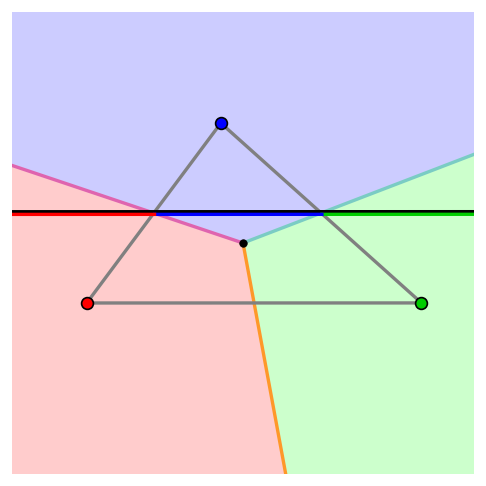

In [387]:
fig, ax = plt.subplots(1, 1, figsize=(5,5))

# 2D origin
if show_origin:
    ax.scatter(0, 0, s=origin_size, color=origin_color, alpha=1.0, marker='o', linewidths=0.5, zorder=0.3)
    if text:
        ax.text(-0.18, -0.16, s=r"$0_2$", size=15, alpha=1.0, color=origin_color, zorder=0.3)

# 2D endmembers
for i in range(M.shape[1]):
    color2D = (1.0, 0.0, 0.0) * (i==0) + (0.0, 0.8, 0.0) * (i==1) + (0.0, 0.0, 1.0) * (i==2) + (0.0, 0.0, 0.0) * (i>=3)
    color2D = np.asarray(color2D) + 1 - endmember_saturation; color2D[color2D>=1] = 1.0; color2D = tuple(color2D)
    ax.scatter(*M[:2,i], s=endmember_size, facecolors=color2D, linewidths=1, color='black', alpha=1.0, marker='o', zorder=0.6)
    if text:
        text_end = r"$M_1(k)$" * (i==0) + r"$M_2(k)$" * (i==1) + r"$M_3(k)$" * (i==2) + r"$M_i(k)$" * (i>=3)
        ax.text(*(M[:2,i]+normed(M[:2,i])*0.2), s=text_end, size=15, alpha=1.0, color=color2D, zorder=0.6)

# 2D endmember simplex
if show_simplex:
    for i in range(M.shape[1]):
        ax.plot([M[0,i-1], M[0,i]], [M[1,i-1], M[1,i]], color=simplex_color, linewidth=simplex_width, zorder=0.5)
    if text:
        anchor_pt = np.array([(M[:2,i-1]+M[:2,i])/2 for i in range(M.shape[1])]); anchor_pt = anchor_pt[np.argmin(norm(anchor_pt)).item()]
        ax.text(*(anchor_pt+normed(anchor_pt)*0.3), s="simplex", size=15, alpha=1.0, color=simplex_color, zorder=0.5)

# 2D separation hyperplane lines
for i in range(len(dirvs)):
    color2D = 'YlOrBr' * (i==0) + 'PuRd' * (i==1) + 'GnBu' * (i==2) if sep_lines_saturation is not None else 'Greys'
    color2D = np.array(plt.get_cmap(color2D)(sep_lines_saturation))
    diri = dirvs[i].copy()
    diri[:2] *= window_lims / np.max(np.abs(diri[:2]))
    ax.plot([0, diri[0]], [0, diri[1]], alpha=1.0, color=color2D, linewidth=sep_lines_width, zorder=0.2)
    if text:
        ... # H_{ij}(k)

# 2D polyhedral-cone regions
if np.linalg.matrix_rank(M[:2]) < 2:
    color2D = np.asarray(np.zeros(3)) + 1 - polyhedra_saturation; color2D[color2D>1] = 1; color2D = tuple(color2D)
    pii = plane_edges
    polygon = Polygon(pii, closed=False, facecolor=color2D, alpha=1.0, linewidth=1.0, antialiased=False, zorder=0.1)
    ax.add_patch(polygon)
else:
    patches = []
    lcolors = []
    for i in range(len(poly_regions)):
        color2D = (1.0, 0.0, 0.0) * (i==0) + (0.0, 0.8, 0.0) * (i==1) + (0.0, 0.0, 1.0) * (i==2)
        color2D = np.asarray(color2D) + 1 - polyhedra_saturation; color2D[color2D>1] = 1; color2D = tuple(color2D)
        pii = poly_regions[i]
        polygon = Polygon(pii, closed=False, facecolor=color2D, alpha=1.0, linewidth=1.0, antialiased=False, zorder=0.1)
        ax.add_patch(polygon)

# 2D affine subspace W(k)
ax.plot([dark_lim_1[0], dark_lim_2[0]], [dark_lim_1[1], dark_lim_2[1]], alpha=1.0, color=(0.0, 0.0, 0.0), linewidth=W_subspace_width, zorder=0.7)
colors_2D = [(1.0, 0.0, 0.0), (0.0, 0.8, 0.0), (0.0, 0.0, 1.0)]
ax.plot([segm_1[0,0], segm_1[1,0]], [segm_1[0,1], segm_1[1,1]], alpha=1.0, color=colors_2D[idx_1], linewidth=W_subspace_width, zorder=0.75)
ax.plot([segm_2[0,0], segm_2[1,0]], [segm_2[0,1], segm_2[1,1]], alpha=1.0, color=colors_2D[idx_2], linewidth=W_subspace_width, zorder=0.75)
ax.plot([segm_3[0,0], segm_3[1,0]], [segm_3[0,1], segm_3[1,1]], alpha=1.0, color=colors_2D[idx_3], linewidth=W_subspace_width, zorder=0.75)

ax.set_xlim(-window_lims, window_lims)
ax.set_ylim(-window_lims, window_lims)
ax.set_axis_off()
ax.set_aspect('equal')

plt.show()

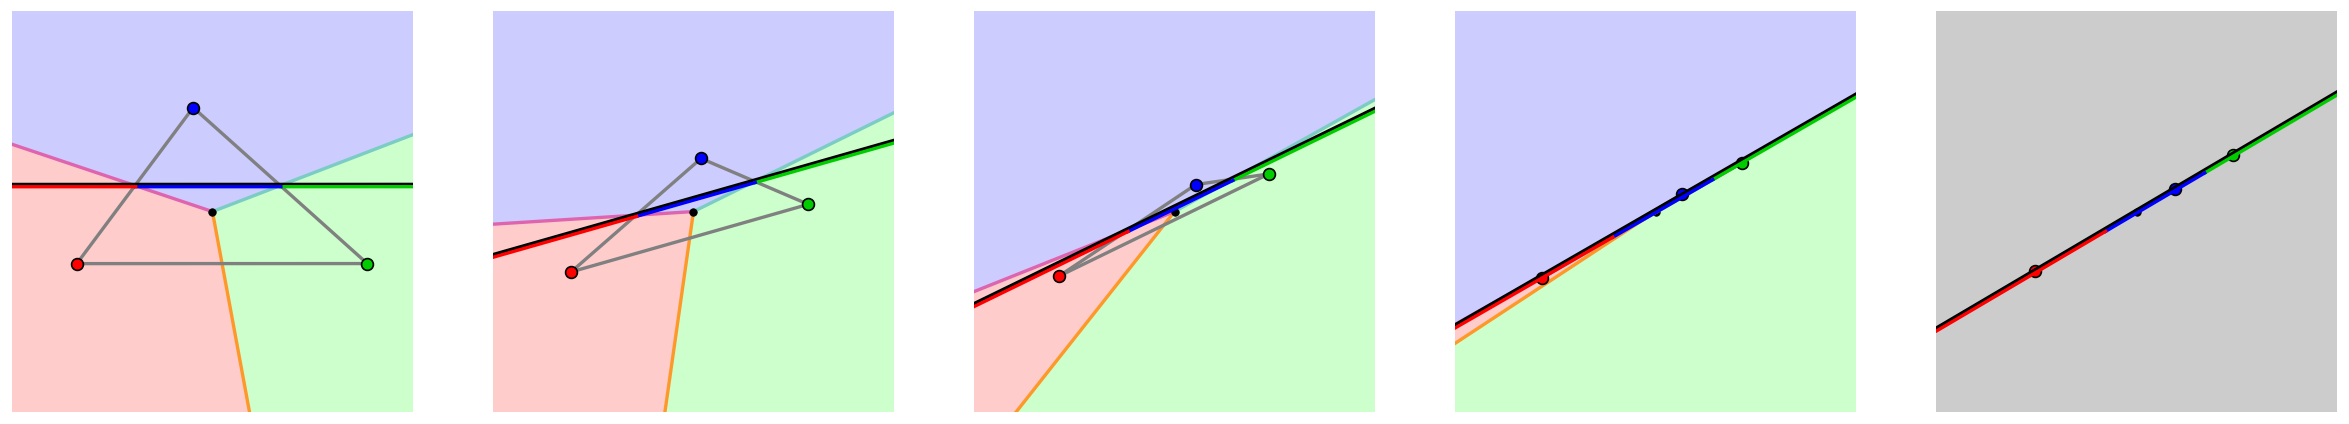

In [ ]:
# Show figures on the same plot!

nbk = 5
power = 3.0

fig, ax = plt.subplots(1, nbk, figsize=(5*nbk,5))

k_linspace = np.linspace(0,1,nbk)[::-1]**power
idx_1, idx_2, idx_3 = 0, 1, 2
for k in range(nbk):
    one_over_k = k_linspace[k]

    M = (M_base.T.copy() * one_over_k + ((proj_M_on_W[:,None] * W_direction) + np.array([0,0,1]) * depth) * (1 - one_over_k)).T

    combi = list(itertools.combinations(range(M.shape[1]),2))
    dirvs = np.asarray([np.mean(M[:2,list(c)], axis=1) - M[:2,list({0,1,2}.difference(c))[0]] for c in combi])

    # Deduce hyperplane lines for 2D projection plane
    hp_dirvs = []
    for diri in dirvs:
        vdir = diri[:2] * window_lims / np.max(np.abs(diri[:2]))
        hp_dirvs.append(vdir)

    # Deduce polyhedral-cone regions for 2D projection plane
    poly_regions = []
    plane_edges = np.asarray([[-1,-1],[-1, 1],[ 1, 1],[ 1,-1]]) * window_lims
    for i in range(M.shape[1]):
        args = np.argwhere(np.sum(np.asarray(combi) == i, axis=-1, dtype=bool)).flatten()
        vecs = np.asarray(hp_dirvs)[list(args)] # edge vectors of polyhedral cone
        ovec = np.asarray([[-vi[1], vi[0]] for vi in vecs])
        ovec*= np.sign(scalar(ovec, vecs - vecs.mean(axis=0), keepdims=True))
        edge_args = np.argwhere(np.max(scalar(plane_edges[:,None], ovec), axis=-1) < 0).flatten()
        edges = plane_edges[list(edge_args)] # vectors inside polyhedral cone
        edge_argsort = np.argsort(scalar(edges, vecs[-1] - vecs[0]))
        sorted_edges = edges[list(edge_argsort)] # sorted vectors inside polyhedral cone
        ptsi = np.concatenate([[[0]*2], vecs[:-1], sorted_edges, vecs[-1:]], axis=0)
        poly_regions.append(ptsi)

    # Center the endmembers!
    def get_center(M:np.ndarray, warning:bool=False) -> np.ndarray:
        """M is of shape (n_endm=3, ndim=2)"""
        frac_up = (M[0,1] - M[1,1]) * (M[0,0] + M[2,0] - 2 * M[1,0]) - (M[0,0] - M[1,0]) * (M[0,1] + M[2,1] - 2 * M[1,1])
        frac_dw = (M[0,1] + M[2,1] - 2 * M[1,1]) * (M[1,0] + M[2,0] - 2 * M[0,0]) - (M[0,0] + M[2,0] - 2 * M[1,0]) * (M[1,1] + M[2,1] - 2 * M[0,1])
        if np.abs(frac_dw) < 1e-12:
            if warning:
                print("Warning: devide by 0 in get_center function")
            return np.asarray([0]*M.shape[1])
        little_x = M[0,0] + frac_up / frac_dw * (M[1,0] + M[2,0] - 2 * M[0,0])
        little_y = M[0,1] + frac_up / frac_dw * (M[1,1] + M[2,1] - 2 * M[0,1])
        return np.asarray([little_x, little_y] + [0] * (M.shape[1]-2))
    M = (M.T - get_center(M.T)).T

    # Compute affine subspace W(k)
    pt_argsort = M.T[np.argsort(proj_M_on_W),:2]
    p1, p2 = (pt_argsort[0] + pt_argsort[1]) / 2, (pt_argsort[2] + pt_argsort[1]) / 2
    vec12 = p2 - p1
    def fp1(x): return vec12[1] / vec12[0] * (x - p1[0]) + p1[1]
    def fm1(y): return vec12[0] / vec12[1] * (y - p1[1]) + p1[0]
    meet_pts = np.asarray([(window_lims, fp1(window_lims)), (-window_lims, fp1(-window_lims)), (fm1(window_lims), window_lims), (fm1(-window_lims), -window_lims)])
    arg_best = np.argsort(scalar(meet_pts - p1, +vec12))
    dircol = normed(np.asarray([W_direction[1], -W_direction[0]]))
    dark_lim_1 = meet_pts[arg_best[-2]] - dircol * W_subspace_width/200
    dark_lim_2 = meet_pts[arg_best[+1]] - dircol * W_subspace_width/200

    # Compute W(k) partitioning
    segm_1 = np.asarray((dark_lim_1, np.asarray([p1,p2])[np.argmin(norm(np.array([p1,p2])-dark_lim_1))] - dircol * W_subspace_width/200)) + dircol * W_subspace_width/100
    segm_3 = np.asarray((dark_lim_2, np.asarray([p1,p2])[np.argmin(norm(np.array([p1,p2])-dark_lim_2))] - dircol * W_subspace_width/200)) + dircol * W_subspace_width/100
    segm_2 = np.asarray((segm_1[1], segm_3[1]))
    idx_1p = np.argmax([path.Path(poly).contains_points([np.mean(segm_1, axis=0)]).item() for poly in poly_regions])
    idx_2p = np.argmax([path.Path(poly).contains_points([np.mean(segm_2, axis=0)]).item() for poly in poly_regions])
    idx_3p = np.argmax([path.Path(poly).contains_points([np.mean(segm_3, axis=0)]).item() for poly in poly_regions])
    if len(np.unique([idx_1p, idx_2p, idx_3p])) == 3:
        idx_1, idx_2, idx_3 = idx_1p, idx_2p, idx_3p

    # 2D origin
    if show_origin:
        ax[k].scatter(0, 0, s=origin_size, color=origin_color, alpha=1.0, marker='o', linewidths=0.5, zorder=0.3)
        if text:
            ax[k].text(-0.18, -0.16, s=r"$0_2$", size=15, alpha=1.0, color=origin_color, zorder=0.3)

    # 2D endmembers
    for i in range(M.shape[1]):
        color2D = (1.0, 0.0, 0.0) * (i==0) + (0.0, 0.8, 0.0) * (i==1) + (0.0, 0.0, 1.0) * (i==2) + (0.0, 0.0, 0.0) * (i>=3)
        color2D = np.asarray(color2D) + 1 - endmember_saturation; color2D[color2D>=1] = 1.0; color2D = tuple(color2D)
        ax[k].scatter(*M[:2,i], s=endmember_size, facecolors=color2D, linewidths=1, color='black', alpha=1.0, marker='o', zorder=0.6)
        if text:
            text_end = r"$M_1(k)$" * (i==0) + r"$M_2(k)$" * (i==1) + r"$M_3(k)$" * (i==2) + r"$M_i(k)$" * (i>=3)
            ax[k].text(*(M[:2,i]+normed(M[:2,i])*0.2), s=text_end, size=15, alpha=1.0, color=color2D, zorder=0.6)

    # 2D endmember simplex
    if show_simplex:
        for i in range(M.shape[1]):
            ax[k].plot([M[0,i-1], M[0,i]], [M[1,i-1], M[1,i]], color=simplex_color, linewidth=simplex_width, zorder=0.5)
        if text:
            anchor_pt = np.array([(M[:2,i-1]+M[:2,i])/2 for i in range(M.shape[1])]); anchor_pt = anchor_pt[np.argmin(norm(anchor_pt)).item()]
            ax[k].text(*(anchor_pt+normed(anchor_pt)*0.3), s="simplex", size=15, alpha=1.0, color=simplex_color, zorder=0.5)

    # 2D separation hyperplane lines
    for i in range(len(dirvs)):
        color2D = 'YlOrBr' * (i==0) + 'PuRd' * (i==1) + 'GnBu' * (i==2) if sep_lines_saturation is not None else 'Greys'
        color2D = np.array(plt.get_cmap(color2D)(sep_lines_saturation))
        diri = dirvs[i].copy()
        diri[:2] *= window_lims / np.max(np.abs(diri[:2]))
        ax[k].plot([0, diri[0]], [0, diri[1]], alpha=1.0, color=color2D, linewidth=sep_lines_width, zorder=0.2)
        if text:
            ... # H_{ij}(k)

    # 2D polyhedral-cone regions
    if np.linalg.matrix_rank(M[:2]) < 2:
        color2D = np.asarray(np.zeros(3)) + 1 - polyhedra_saturation; color2D[color2D>1] = 1; color2D = tuple(color2D)
        pii = plane_edges
        polygon = Polygon(pii, closed=False, facecolor=color2D, alpha=1.0, linewidth=1.0, antialiased=False, zorder=0.1)
        ax[k].add_patch(polygon)
    else:
        patches = []
        lcolors = []
        for i in range(len(poly_regions)):
            color2D = (1.0, 0.0, 0.0) * (i==0) + (0.0, 0.8, 0.0) * (i==1) + (0.0, 0.0, 1.0) * (i==2)
            color2D = np.asarray(color2D) + 1 - polyhedra_saturation; color2D[color2D>1] = 1; color2D = tuple(color2D)
            pii = poly_regions[i]
            polygon = Polygon(pii, closed=False, facecolor=color2D, alpha=1.0, linewidth=1.0, antialiased=False, zorder=0.1)
            ax[k].add_patch(polygon)

    # 2D affine subspace W(k)
    ax[k].plot([dark_lim_1[0], dark_lim_2[0]], [dark_lim_1[1], dark_lim_2[1]], alpha=1.0, color=(0.0, 0.0, 0.0), linewidth=W_subspace_width, zorder=0.7)
    colors_2D = [(1.0, 0.0, 0.0), (0.0, 0.8, 0.0), (0.0, 0.0, 1.0)]
    ax[k].plot([segm_1[0,0], segm_1[1,0]], [segm_1[0,1], segm_1[1,1]], alpha=1.0, color=colors_2D[idx_1], linewidth=W_subspace_width, zorder=0.75)
    ax[k].plot([segm_2[0,0], segm_2[1,0]], [segm_2[0,1], segm_2[1,1]], alpha=1.0, color=colors_2D[idx_2], linewidth=W_subspace_width, zorder=0.75)
    ax[k].plot([segm_3[0,0], segm_3[1,0]], [segm_3[0,1], segm_3[1,1]], alpha=1.0, color=colors_2D[idx_3], linewidth=W_subspace_width, zorder=0.75)

    ax[k].set_xlim(-window_lims, window_lims)
    ax[k].set_ylim(-window_lims, window_lims)
    ax[k].set_axis_off()
    ax[k].set_aspect('equal')

plt.show()

---

In [ ]:
# Save figures independently!

nbk = 5
power = 3.0
name = 'dependence_step_'

k_linspace = np.linspace(0,1,nbk)[::-1]**power
idx_1, idx_2, idx_3 = 0, 1, 2
for k in range(nbk):
    one_over_k = k_linspace[k]

    M = (M_base.T.copy() * one_over_k + ((proj_M_on_W[:,None] * W_direction) + np.array([0,0,1]) * depth) * (1 - one_over_k)).T

    combi = list(itertools.combinations(range(M.shape[1]),2))
    dirvs = np.asarray([np.mean(M[:2,list(c)], axis=1) - M[:2,list({0,1,2}.difference(c))[0]] for c in combi])

    # Deduce hyperplane lines for 2D projection plane
    hp_dirvs = []
    for diri in dirvs:
        vdir = diri[:2] * window_lims / np.max(np.abs(diri[:2]))
        hp_dirvs.append(vdir)

    # Deduce polyhedral-cone regions for 2D projection plane
    poly_regions = []
    plane_edges = np.asarray([[-1,-1],[-1, 1],[ 1, 1],[ 1,-1]]) * window_lims
    for i in range(M.shape[1]):
        args = np.argwhere(np.sum(np.asarray(combi) == i, axis=-1, dtype=bool)).flatten()
        vecs = np.asarray(hp_dirvs)[list(args)] # edge vectors of polyhedral cone
        ovec = np.asarray([[-vi[1], vi[0]] for vi in vecs])
        ovec*= np.sign(scalar(ovec, vecs - vecs.mean(axis=0), keepdims=True))
        edge_args = np.argwhere(np.max(scalar(plane_edges[:,None], ovec), axis=-1) < 0).flatten()
        edges = plane_edges[list(edge_args)] # vectors inside polyhedral cone
        edge_argsort = np.argsort(scalar(edges, vecs[-1] - vecs[0]))
        sorted_edges = edges[list(edge_argsort)] # sorted vectors inside polyhedral cone
        ptsi = np.concatenate([[[0]*2], vecs[:-1], sorted_edges, vecs[-1:]], axis=0)
        poly_regions.append(ptsi)

    # Center the endmembers!
    def get_center(M:np.ndarray, warning:bool=False) -> np.ndarray:
        """M is of shape (n_endm=3, ndim=2)"""
        frac_up = (M[0,1] - M[1,1]) * (M[0,0] + M[2,0] - 2 * M[1,0]) - (M[0,0] - M[1,0]) * (M[0,1] + M[2,1] - 2 * M[1,1])
        frac_dw = (M[0,1] + M[2,1] - 2 * M[1,1]) * (M[1,0] + M[2,0] - 2 * M[0,0]) - (M[0,0] + M[2,0] - 2 * M[1,0]) * (M[1,1] + M[2,1] - 2 * M[0,1])
        if np.abs(frac_dw) < 1e-12:
            if warning:
                print("Warning: devide by 0 in get_center function")
            return np.asarray([0]*M.shape[1])
        little_x = M[0,0] + frac_up / frac_dw * (M[1,0] + M[2,0] - 2 * M[0,0])
        little_y = M[0,1] + frac_up / frac_dw * (M[1,1] + M[2,1] - 2 * M[0,1])
        return np.asarray([little_x, little_y] + [0] * (M.shape[1]-2))
    M = (M.T - get_center(M.T)).T

    # Compute affine subspace W(k)
    pt_argsort = M.T[np.argsort(proj_M_on_W),:2]
    p1, p2 = (pt_argsort[0] + pt_argsort[1]) / 2, (pt_argsort[2] + pt_argsort[1]) / 2
    vec12 = p2 - p1
    def fp1(x): return vec12[1] / vec12[0] * (x - p1[0]) + p1[1]
    def fm1(y): return vec12[0] / vec12[1] * (y - p1[1]) + p1[0]
    meet_pts = np.asarray([(window_lims, fp1(window_lims)), (-window_lims, fp1(-window_lims)), (fm1(window_lims), window_lims), (fm1(-window_lims), -window_lims)])
    arg_best = np.argsort(scalar(meet_pts - p1, +vec12))
    dircol = normed(np.asarray([W_direction[1], -W_direction[0]]))
    dark_lim_1 = meet_pts[arg_best[-2]] - dircol * W_subspace_width/200
    dark_lim_2 = meet_pts[arg_best[+1]] - dircol * W_subspace_width/200

    # Compute W(k) partitioning
    segm_1 = np.asarray((dark_lim_1, np.asarray([p1,p2])[np.argmin(norm(np.array([p1,p2])-dark_lim_1))] - dircol * W_subspace_width/200)) + dircol * W_subspace_width/100
    segm_3 = np.asarray((dark_lim_2, np.asarray([p1,p2])[np.argmin(norm(np.array([p1,p2])-dark_lim_2))] - dircol * W_subspace_width/200)) + dircol * W_subspace_width/100
    segm_2 = np.asarray((segm_1[1], segm_3[1]))
    idx_1p = np.argmax([path.Path(poly).contains_points([np.mean(segm_1, axis=0)]).item() for poly in poly_regions])
    idx_2p = np.argmax([path.Path(poly).contains_points([np.mean(segm_2, axis=0)]).item() for poly in poly_regions])
    idx_3p = np.argmax([path.Path(poly).contains_points([np.mean(segm_3, axis=0)]).item() for poly in poly_regions])
    if len(np.unique([idx_1p, idx_2p, idx_3p])) == 3:
        idx_1, idx_2, idx_3 = idx_1p, idx_2p, idx_3p

    fig, ax = plt.subplots(1, 1, figsize=(5,5))

    # 2D origin
    if show_origin:
        ax.scatter(0, 0, s=origin_size, color=origin_color, alpha=1.0, marker='o', linewidths=0.5, zorder=0.3)
        if text:
            ax.text(-0.18, -0.16, s=r"$0_2$", size=15, alpha=1.0, color=origin_color, zorder=0.3)

    # 2D endmembers
    for i in range(M.shape[1]):
        color2D = (1.0, 0.0, 0.0) * (i==0) + (0.0, 0.8, 0.0) * (i==1) + (0.0, 0.0, 1.0) * (i==2) + (0.0, 0.0, 0.0) * (i>=3)
        color2D = np.asarray(color2D) + 1 - endmember_saturation; color2D[color2D>=1] = 1.0; color2D = tuple(color2D)
        ax.scatter(*M[:2,i], s=endmember_size, facecolors=color2D, linewidths=1, color='black', alpha=1.0, marker='o', zorder=0.6)
        if text:
            text_end = r"$M_1(k)$" * (i==0) + r"$M_2(k)$" * (i==1) + r"$M_3(k)$" * (i==2) + r"$M_i(k)$" * (i>=3)
            ax.text(*(M[:2,i]+normed(M[:2,i])*0.2), s=text_end, size=15, alpha=1.0, color=color2D, zorder=0.6)

    # 2D endmember simplex
    if show_simplex:
        for i in range(M.shape[1]):
            ax.plot([M[0,i-1], M[0,i]], [M[1,i-1], M[1,i]], color=simplex_color, linewidth=simplex_width, zorder=0.5)
        if text:
            anchor_pt = np.array([(M[:2,i-1]+M[:2,i])/2 for i in range(M.shape[1])]); anchor_pt = anchor_pt[np.argmin(norm(anchor_pt)).item()]
            ax.text(*(anchor_pt+normed(anchor_pt)*0.3), s="simplex", size=15, alpha=1.0, color=simplex_color, zorder=0.5)

    # 2D separation hyperplane lines
    for i in range(len(dirvs)):
        color2D = 'YlOrBr' * (i==0) + 'PuRd' * (i==1) + 'GnBu' * (i==2) if sep_lines_saturation is not None else 'Greys'
        color2D = np.array(plt.get_cmap(color2D)(sep_lines_saturation))
        diri = dirvs[i].copy()
        diri[:2] *= window_lims / np.max(np.abs(diri[:2]))
        ax.plot([0, diri[0]], [0, diri[1]], alpha=1.0, color=color2D, linewidth=sep_lines_width, zorder=0.2)
        if text:
            ... # H_{ij}(k)

    # 2D polyhedral-cone regions
    if np.linalg.matrix_rank(M[:2]) < 2:
        color2D = np.asarray(np.zeros(3)) + 1 - polyhedra_saturation; color2D[color2D>1] = 1; color2D = tuple(color2D)
        pii = plane_edges
        polygon = Polygon(pii, closed=False, facecolor=color2D, alpha=1.0, linewidth=1.0, antialiased=False, zorder=0.1)
        ax.add_patch(polygon)
    else:
        patches = []
        lcolors = []
        for i in range(len(poly_regions)):
            color2D = (1.0, 0.0, 0.0) * (i==0) + (0.0, 0.8, 0.0) * (i==1) + (0.0, 0.0, 1.0) * (i==2)
            color2D = np.asarray(color2D) + 1 - polyhedra_saturation; color2D[color2D>1] = 1; color2D = tuple(color2D)
            pii = poly_regions[i]
            polygon = Polygon(pii, closed=False, facecolor=color2D, alpha=1.0, linewidth=1.0, antialiased=False, zorder=0.1)
            ax.add_patch(polygon)

    # 2D affine subspace W(k)
    ax.plot([dark_lim_1[0], dark_lim_2[0]], [dark_lim_1[1], dark_lim_2[1]], alpha=1.0, color=(0.0, 0.0, 0.0), linewidth=W_subspace_width, zorder=0.7)
    colors_2D = [(1.0, 0.0, 0.0), (0.0, 0.8, 0.0), (0.0, 0.0, 1.0)]
    ax.plot([segm_1[0,0], segm_1[1,0]], [segm_1[0,1], segm_1[1,1]], alpha=1.0, color=colors_2D[idx_1], linewidth=W_subspace_width, zorder=0.75)
    ax.plot([segm_2[0,0], segm_2[1,0]], [segm_2[0,1], segm_2[1,1]], alpha=1.0, color=colors_2D[idx_2], linewidth=W_subspace_width, zorder=0.75)
    ax.plot([segm_3[0,0], segm_3[1,0]], [segm_3[0,1], segm_3[1,1]], alpha=1.0, color=colors_2D[idx_3], linewidth=W_subspace_width, zorder=0.75)

    ax.set_xlim(-window_lims, window_lims)
    ax.set_ylim(-window_lims, window_lims)
    ax.set_axis_off()
    ax.set_aspect('equal')
    
    fig.savefig(folder + name + str(k+1) + '.' + extension.lower(), bbox_inches='tight', pad_inches=0, transparent=True)
    plt.close()